# K-Means Clustering

In [1]:
#
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

#
data_frame = pd.read_csv(r"D:\CCI230_InteligenciaArtificial\Kmenas_PCA\archive\Country-data.csv")
print(data_frame.to_string())

entrdas = data_frame.iloc[:, 1:10]
saida = data_frame.iloc[:, 0]

# Normalizar as entradas
pca_model = PCA(n_components=2)
entrada_padrao = StandardScaler().fit_transform(entrdas)
duas_dimensoes = pca_model.fit_transform(entrdas)

# Converte 'saida' para valores numéricos
label_encoder = LabelEncoder()
saida_numerica = label_encoder.fit_transform(saida)

                            country  child_mort  exports  health   imports  income  inflation  life_expec  total_fer    gdpp
0                       Afghanistan        90.2   10.000    7.58   44.9000    1610      9.440        56.2       5.82     553
1                           Albania        16.6   28.000    6.55   48.6000    9930      4.490        76.3       1.65    4090
2                           Algeria        27.3   38.400    4.17   31.4000   12900     16.100        76.5       2.89    4460
3                            Angola       119.0   62.300    2.85   42.9000    5900     22.400        60.1       6.16    3530
4               Antigua and Barbuda        10.3   45.500    6.03   58.9000   19100      1.440        76.8       2.13   12200
5                         Argentina        14.5   18.900    8.10   16.0000   18700     20.900        75.8       2.37   10300
6                           Armenia        18.1   20.800    4.40   45.3000    6700      7.770        73.3       1.69    3220


Metodo do cotovelo para definir a quandida de clusters.

Text(0, 0.5, 'Inertia')

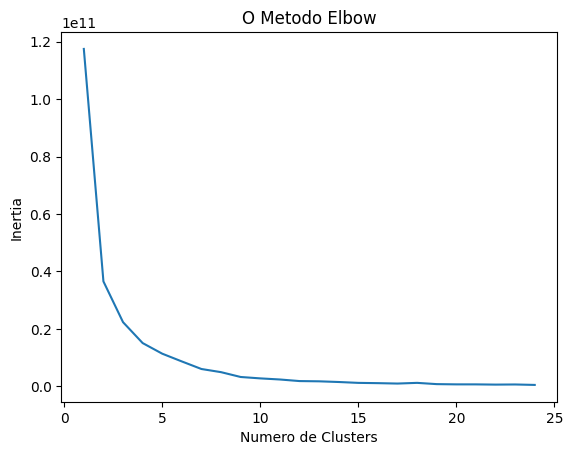

In [2]:
inertia = []
for i in range(1, 25):
    kmeans = KMeans(n_clusters=i, init='k-means++')
    kmeans.fit(duas_dimensoes)
    inertia.append(kmeans.inertia_)

plt.plot(list(range(1, 25)), inertia)
plt.title('O Metodo Elbow')
plt.xlabel('Numero de Clusters')
plt.ylabel('Inertia')

Text(0, 0.5, 'Inertia')

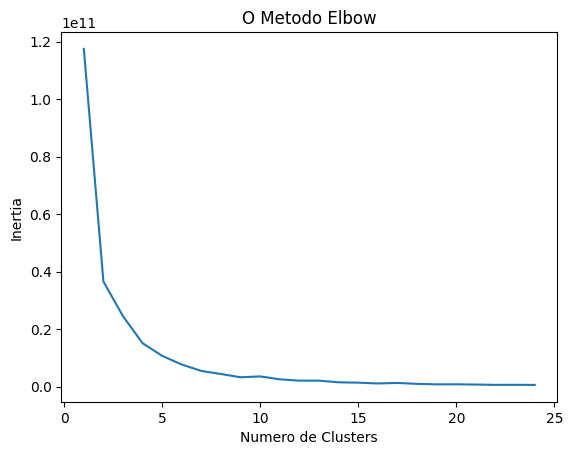

In [3]:
inertia = []
for i in range(1, 25):
    kmeans = KMeans(n_clusters=i, n_init='auto')
    kmeans.fit(duas_dimensoes)
    inertia.append(kmeans.inertia_)

plt.plot(list(range(1, 25)), inertia)
plt.title('O Metodo Elbow')
plt.xlabel('Numero de Clusters')
plt.ylabel('Inertia')

a partir da anilse do grafi de saida do medoto do cotovelo (elbow), podemos considerar que um numero adequade de clusets para a o treinamento do modelo k-menas sera 12 agrupamentos.

Colunas escolhidas pelo PCA (nomes): [['gdpp' 'income']
 ['income' 'gdpp']]


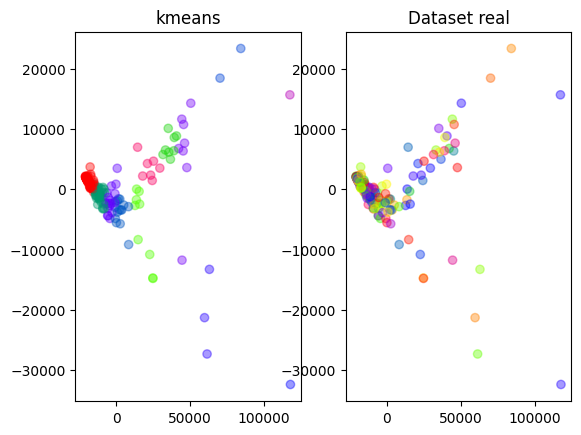

In [4]:
kmeans = KMeans(n_clusters=12, init='k-means++')
kmeans.fit(duas_dimensoes)
solucao = kmeans.predict(duas_dimensoes)

plt.subplot(1, 2, 1)
plt.scatter(duas_dimensoes[:, 0], duas_dimensoes[:, 1], c=solucao, alpha=0.4, cmap='prism')
plt.title("kmeans")

plt.subplot(1, 2, 2)
plt.scatter(duas_dimensoes[:, 0], duas_dimensoes[:, 1], c=saida_numerica, alpha=0.4, cmap='prism')
plt.title("Dataset real")

#* esse algorimo faz com saibamos qual foram as componets escolinhas pelo PCA
colunas_escolhidas = np.argsort(np.abs(pca_model.components_), axis=1)[:, -2:]
colunas_escolhidas_nomes = np.array(entrdas.columns)[colunas_escolhidas]
print("Colunas escolhidas pelo PCA (nomes):", colunas_escolhidas_nomes)


Clusters Identificados: O K-Means identificou 15 clusters distintos nos dados. Cada ponto no gráfico de dispersão representa uma observação, colorida de acordo com o cluster ao qual pertence.

O eixo x representa o gdpp, enquanto o eixo y representa a income. A partir desses dois eixos, você pode visualizar como a renda e o PIB per capita influenciam a formação dos clusters.

A escolha de gdpp e income como principais componentes indica que a estrutura dos clusters está fortemente ligada ao nível de desenvolvimento econômico. A análise dos clusters permite entender como diferentes países ou regiões se agrupam de acordo com essas variáveis, revelando padrões de similaridade em termos de renda e PIB per capita.